In [ ]:
!pip install nltk

In [145]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/arnab/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/arnab/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [146]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/arnab/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [147]:
!pip install kagglehub

In [148]:
import kagglehub

path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Path to dataset files: /home/arnab/.cache/kagglehub/datasets/adityajn105/flickr8k/versions/1


In [ ]:
import torch
torch.cuda.empty_cache()

if encoder:
    del encoder

if decoder:
    del decoder

torch.cuda.empty_cache()

In [150]:
import os
import re
import json
import random
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# For evaluation:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

In [151]:
EMBED_SIZE = 512        # Larger embedding for better representations
HIDDEN_SIZE = 512       # Good balance of capacity and speed
NUM_LAYERS = 1          # Keep single layer for speed
BATCH_SIZE = 64         # 4060 can handle this with mixed precision
LR = 3e-4               # Good learning rate for Adam
EPOCHS = 3              # As required by assignment
MAX_SEQ_LEN = 20        # Reasonable caption length
MIN_WORD_FREQ = 5       # Good vocabulary size
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Enable mixed precision training for speed boost
USE_AMP = True          # Automatic Mixed Precision

print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.18 GB


In [152]:
def collate_fn(batch):
    """
    Collate function for Flickr dataset.
    Sorts by caption length (descending) for packing.
    """
    # Unpack dataset outputs
    imgs, caps, lengths, names = zip(*batch)

    # Stack images
    imgs = torch.stack(imgs, 0)

    # Convert captions to tensor
    caps = torch.stack(caps, 0)

    # Lengths are already known
    lengths = torch.tensor(lengths)

    return imgs, caps, lengths, names

In [153]:
# ------------ Simple Vocabulary builder -------------
class Vocabulary:
    def __init__(self, freq_threshold=MIN_WORD_FREQ):
        self.freq_threshold = freq_threshold
        self.word2idx = {"<pad>":0, "<start>":1, "<end>":2, "<unk>":3}
        self.idx2word = {0:"<pad>", 1:"<start>", 2:"<end>", 3:"<unk>"}
        self.freqs = Counter()
        self.next_idx = 4

    def tokenize(self, text):
        text = text.lower()
        # simple tokenization; students can replace with better tokenizer
        tokens = re.findall(r"\w+", text)
        return tokens

    def build_vocab(self, captions_list):
        for caption in captions_list:
            tokens = self.tokenize(caption)
            self.freqs.update(tokens)
        for word, cnt in self.freqs.items():
            if cnt >= self.freq_threshold:
                self.word2idx[word] = self.next_idx
                self.idx2word[self.next_idx] = word
                self.next_idx += 1

    def numericalize(self, text):
        tokens = self.tokenize(text)
        return [self.word2idx.get(tok, self.word2idx["<unk>"]) for tok in tokens]

In [154]:
class FlickrDataset(Dataset):
    def __init__(self, images_dir, captions_file, vocab, transform=None, max_len=50):
        self.images_dir = images_dir
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len
        
        # Dictionary to store all captions for each image
        self.img_caps = {}

        with open(captions_file, 'r') as f:
            lines = [l.strip() for l in f.readlines() if len(l.strip()) > 0]

        # Handle CSV or TSV formats
        if ',' in lines[0] and '\t' not in lines[0]:
            if 'image' in lines[0].lower():  # skip header
                lines = lines[1:]
            self.data = []
            for line in lines:
                if ',' in line:
                    parts = line.split(',', 1)
                    if len(parts) == 2:
                        img_name, caption = parts
                        self.data.append((img_name, caption))
                        # Store caption for this image
                        if img_name not in self.img_caps:
                            self.img_caps[img_name] = []
                        self.img_caps[img_name].append(caption)
        else:
            self.data = []
            for line in lines:
                if '\t' in line:
                    img, cap = line.split('\t')
                    img_name = img.split('#')[0]
                    self.data.append((img_name, cap))
                    # Store caption for this image
                    if img_name not in self.img_caps:
                        self.img_caps[img_name] = []
                    self.img_caps[img_name].append(cap)

        print(f"✅ Parsed {len(self.data)} image-caption pairs")
        print(f"✅ Found {len(self.img_caps)} unique images")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]
        img_path = os.path.join(self.images_dir, img_name)

        # Load image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Tokenize caption
        tokens = [self.vocab.word2idx.get("<start>")] + [
            self.vocab.word2idx.get(word.lower(), self.vocab.word2idx["<unk>"]) 
            for word in caption.split()
        ] + [self.vocab.word2idx.get("<end>")]

        # Pad sequence
        if len(tokens) < self.max_len:
            tokens += [self.vocab.word2idx["<pad>"]] * (self.max_len - len(tokens))
        else:
            tokens = tokens[:self.max_len]

        return image, torch.tensor(tokens), len(tokens), img_name

In [155]:
# ------------- Simple CNN encoder (small) -------------
class SmallCNNEncoder(nn.Module):
    def __init__(self, embed_size=EMBED_SIZE):
        super().__init__()
        # Very small conv net for demonstrative purposes
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 3 -> 32
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(64, embed_size)

    def forward(self, images):
        x = self.features(images)         # (B, 64, 1, 1)
        x = x.view(x.size(0), -1)         # (B, 64)
        x = self.fc(x)                    # (B, embed_size)
        return x


In [156]:
# ------------- Decoder: simple vanilla RNN decoder -------------
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        # vanilla RNN cell
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

        # map image embedding to initial hidden
        self.img2hid = nn.Linear(embed_size, hidden_size)

    def forward(self, img_feats, captions, lengths):
        """
        img_feats: (B, embed_size)
        captions: (B, seq_len) with <start> ... <end> tokens
        lengths: list of lengths
        """
        embeddings = self.embed(captions)  # (B, seq_len, embed_size)
        # prepend image feature as time step 0 (or use as hidden init)
        h0 = torch.tanh(self.img2hid(img_feats)).unsqueeze(0)  # (num_layers, B, H)
        outputs, _ = self.rnn(embeddings, h0)   # (B, seq_len, H)
        outputs = self.fc(outputs)              # (B, seq_len, vocab)
        return outputs

    def sample(self, img_feats, vocab, max_len=MAX_SEQ_LEN):
        """Greedy sampling for demo/test"""
        self.eval()
        with torch.no_grad():
            hidden = torch.tanh(self.img2hid(img_feats)).unsqueeze(0)  # (1, B, H)
            inputs = torch.tensor([vocab.word2idx["<start>"]]*img_feats.size(0), device=img_feats.device).unsqueeze(1)  # (B,1)
            captions = []
            for _ in range(max_len):
                emb = self.embed(inputs)  # (B,1,embed)
                out, hidden = self.rnn(emb, hidden)  # out (B,1,H)
                out = self.fc(out.squeeze(1))  # (B, vocab)
                _, predicted = out.max(1)      # (B,)
                captions.append(predicted.unsqueeze(1))
                inputs = predicted.unsqueeze(1)
            captions = torch.cat(captions, dim=1)  # (B, max_len)
        return captions  # indices

In [157]:
# ------------- Utility helpers -------------
def idxs_to_sentence(idxs, vocab):
    words = []
    for idx in idxs:
        w = vocab.idx2word.get(int(idx), "<unk>")
        if w == "<end>":
            break
        if w not in ("<start>", "<pad>"):
            words.append(w)
    return " ".join(words)

def visualize_prediction(img_path, pred_sentence, title=None):
    img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title if title else pred_sentence)
    plt.show()


In [158]:
def train_demo(images_dir, captions_txt, vocab, encoder, decoder, 
                    save_name='demo_model.pth', epochs=EPOCHS):
    """Optimized training with mixed precision for RTX 4060"""
    
    print(f"Vocab size: {len(vocab.word2idx)}")
    
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    dataset = FlickrDataset(images_dir, captions_txt, vocab, 
                           transform=transform, max_len=MAX_SEQ_LEN)
    
    # Use num_workers for faster data loading
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, 
                           collate_fn=collate_fn, num_workers=4, 
                           pin_memory=True, persistent_workers=True)

    criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx["<pad>"])
    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = optim.AdamW(params, lr=LR, weight_decay=1e-4)
    
    # Mixed precision training
    scaler = torch.cuda.amp.GradScaler() if USE_AMP and torch.cuda.is_available() else None

    # Training loop
    import time
    start_time = time.time()
    
    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        total_loss = 0
        epoch_start = time.time()
        
        for imgs, caps, lengths, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs = imgs.to(DEVICE, non_blocking=True)
            caps = caps.to(DEVICE, non_blocking=True)
            
            optimizer.zero_grad()
            
            # Mixed precision forward pass
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    img_feats = encoder(imgs)
                    outputs = decoder(img_feats, caps[:, :-1], lengths)
                    targets = caps[:, 1:]
                    outputs = outputs.reshape(-1, outputs.size(2))
                    targets = targets.reshape(-1)
                    loss = criterion(outputs, targets)
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(params, 5.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                img_feats = encoder(imgs)
                outputs = decoder(img_feats, caps[:, :-1], lengths)
                targets = caps[:, 1:]
                outputs = outputs.reshape(-1, outputs.size(2))
                targets = targets.reshape(-1)
                loss = criterion(outputs, targets)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(params, 5.0)
                optimizer.step()
            
            total_loss += loss.item()
        
        epoch_time = time.time() - epoch_start
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1} loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")

    total_time = time.time() - start_time
    print(f"\nTotal training time: {total_time/60:.1f} minutes")
    
    # Save model
    torch.save({
        'encoder': encoder.state_dict(),
        'decoder': decoder.state_dict(),
        'vocab': vocab.word2idx
    }, save_name)
    print(f"Saved {save_name}")

    # Evaluation
    encoder.eval()
    decoder.eval()
    
    print("\n" + "="*60)
    print("SAMPLE PREDICTIONS:")
    print("="*60)
    
    sample_loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
    imgs, caps, lengths, names = next(iter(sample_loader))
    imgs = imgs.to(DEVICE)
    
    with torch.no_grad():
        feats = encoder(imgs)
        sampled = decoder.sample(feats, vocab)
    
    sampled = sampled.cpu().numpy()
    
    for i in range(min(3, sampled.shape[0])):
        pred = idxs_to_sentence(sampled[i], vocab)
        print(f"\nImage: {names[i]}")
        print(f"Prediction: {pred}")
        if names[i] in dataset.img_caps:
            print(f"Ground truth: {dataset.img_caps[names[i]][0]}")

    # Compute metrics on subset
    print("\n" + "="*60)
    print("COMPUTING METRICS...")
    print("="*60)
    
    refs_all = []
    hyps_all = []
    
    eval_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, 
                            collate_fn=collate_fn, num_workers=2)
    
    num_eval_samples = min(500, len(dataset))
    samples_processed = 0
    
    with torch.no_grad():
        for imgs, caps, lengths, names in eval_loader:
            if samples_processed >= num_eval_samples:
                break
            
            imgs = imgs.to(DEVICE)
            feats = encoder(imgs)
            sampled = decoder.sample(feats, vocab).cpu().numpy()
            
            for j in range(sampled.shape[0]):
                if samples_processed >= num_eval_samples:
                    break
                
                pred = idxs_to_sentence(sampled[j], vocab)
                hyps_all.append(pred.split())
                
                refs = []
                if names[j] in dataset.img_caps:
                    for r in dataset.img_caps[names[j]]:
                        refs.append(r.lower().split())
                else:
                    refs.append([])
                
                refs_all.append(refs)
                samples_processed += 1

    # Calculate metrics
    smooth = SmoothingFunction().method1
    bleu1 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], 
                                   weights=(1,0,0,0), 
                                   smoothing_function=smooth) 
                    for i in range(len(hyps_all))])
    bleu4 = np.mean([sentence_bleu(refs_all[i], hyps_all[i], 
                                   weights=(0.25,0.25,0.25,0.25), 
                                   smoothing_function=smooth) 
                    for i in range(len(hyps_all))])
    
    try:
        meteor = np.mean([meteor_score(refs_all[i], hyps_all[i]) 
                         for i in range(len(hyps_all))])
    except:
        meteor = 0.0
    
    print(f"\nEvaluation Results:")
    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")
    print(f"METEOR: {meteor:.4f}")
    
    return bleu1, bleu4, meteor

In [159]:
print("Building vocabulary...")
caps = []
with open(CAPTIONS_FILE, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    if 'image' in lines[0].lower():  # Skip CSV header
        lines = lines[1:]
    for line in lines:
        line = line.strip()
        if not line: 
            continue
        if ',' in line:
            parts = line.split(',', 1)
            if len(parts) == 2:
                caps.append(parts[1])

vocab = Vocabulary(freq_threshold=MIN_WORD_FREQ)
vocab.build_vocab(caps)
print(f"Vocab size: {len(vocab.word2idx)}")

Building vocabulary...
Vocab size: 2982


In [160]:
 # Update these paths to where you unzipped Flickr8k_Dataset and the text file
IMAGES_DIR = "Flicker8k_Dataset"
CAPTIONS_FILE = "captions.txt"

encoder = SmallCNNEncoder(EMBED_SIZE).to(DEVICE)
decoder = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, len(vocab.word2idx), NUM_LAYERS).to(DEVICE)

scores=train_demo(IMAGES_DIR, CAPTIONS_FILE, vocab, encoder, decoder)
print(scores)

Vocab size: 2982


/tmp/ipykernel_10436/2335368584.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_AMP and torch.cuda.is_available() else None


✅ Parsed 40455 image-caption pairs
✅ Found 8091 unique images


Epoch 1/3:   0%|          | 0/633 [00:00<?, ?it/s]/tmp/ipykernel_10436/2335368584.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/3: 100%|██████████| 633/633 [01:02<00:00, 10.19it/s]


Epoch 1 loss: 3.7162 | Time: 62.1s


Epoch 2/3: 100%|██████████| 633/633 [01:01<00:00, 10.24it/s]


Epoch 2 loss: 3.1020 | Time: 61.8s


Epoch 3/3: 100%|██████████| 633/633 [00:59<00:00, 10.73it/s]


Epoch 3 loss: 2.9149 | Time: 59.0s

Total training time: 3.0 minutes
Saved demo_model.pth

SAMPLE PREDICTIONS:

Image: 2743652730_d909c7ae82.jpg
Prediction: a man is standing on a bench <unk>
Ground truth: A boy looks out the window at another boy who is spraying the window with water .

Image: 3096918227_f9d26a7db2.jpg
Prediction: a man is standing on a bench <unk>
Ground truth: "A skateboarder is performing a grab trick while hovering above a ramp , which is located within a city ."

Image: 2544182005_3aa1332bf9.jpg
Prediction: a black dog is running through the snow <unk>
Ground truth: A little boy with a blue shirt is wearing a helmet and riding a two wheeled bike .

COMPUTING METRICS...

Evaluation Results:
BLEU-1: 0.4317
BLEU-4: 0.0936
METEOR: 0.2593
(np.float64(0.4317136914512935), np.float64(0.0936254711153482), np.float64(0.2592978880700529))


In [161]:
import os

print("File exists:", os.path.exists("captions.txt"))
if os.path.exists("captions.txt"):
    with open("captions.txt", "r", encoding="utf-8") as f:
        lines = f.readlines()
    print("Number of lines:", len(lines))
    print("First 3 lines:\n", lines[:3])


File exists: True
Number of lines: 40456
First 3 lines:
 ['image,caption\n', '1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .\n', '1000268201_693b08cb0e.jpg,A girl going into a wooden building .\n']


In [162]:
!head -n 20 /home/arnab/code/collegeCode/sem5-codebases/DL/captions.txt


image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .
1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a wooden cabin .
1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with each other on the road .
1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots are staring at each other in the street .
1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each other on the road .
1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .
1002674143_1b742ab4b8.jpg,A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
1002674143_1b742ab4b8

#Question (10 marks total). You have the boilerplate image-captioning code provided in the lab (Flickr8k, PyTorch). Perform the tasks below and submit: (i) modified code files or diff, results and answers. Label your answers (a)–(d).

##(a) Replace the vanilla RNN decoder with an LSTM decoder and run a short training (3 epochs). (3 marks)

Implement DecoderLSTM (or use the provided one). Ensure sample() and forward() APIs match the original so the training loop needs minimal change.

---
### Solution QA

In [163]:
class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.img2hid = nn.Linear(embed_size, hidden_size)
        self.img2cell = nn.Linear(embed_size, hidden_size)

    def forward(self, img_feats, captions, lengths):
        embeddings = self.embed(captions)
        h0 = torch.tanh(self.img2hid(img_feats)).unsqueeze(0)
        c0 = torch.tanh(self.img2cell(img_feats)).unsqueeze(0)
        outputs, _ = self.lstm(embeddings, (h0, c0))
        outputs = self.fc(outputs)
        return outputs

    def sample(self, img_feats, vocab, max_len=MAX_SEQ_LEN):
        self.eval()
        with torch.no_grad():
            h = torch.tanh(self.img2hid(img_feats)).unsqueeze(0)
            c = torch.tanh(self.img2cell(img_feats)).unsqueeze(0)
            inputs = torch.tensor([vocab.word2idx["<start>"]] * img_feats.size(0), 
                                  device=img_feats.device).unsqueeze(1)
            captions = []
            for _ in range(max_len):
                emb = self.embed(inputs)
                out, (h, c) = self.lstm(emb, (h, c))
                out = self.fc(out.squeeze(1))
                _, predicted = out.max(1)
                captions.append(predicted.unsqueeze(1))
                inputs = predicted.unsqueeze(1)
            captions = torch.cat(captions, dim=1)
        return captions

In [164]:
decoder = DecoderLSTM(EMBED_SIZE, HIDDEN_SIZE, len(vocab.word2idx), NUM_LAYERS).to(DEVICE)
scores_lstm=train_demo(IMAGES_DIR, CAPTIONS_FILE, vocab, encoder, decoder, save_name='demo_lstm_model.pth')
print(scores_lstm)

Vocab size: 2982


/tmp/ipykernel_10436/2335368584.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_AMP and torch.cuda.is_available() else None


✅ Parsed 40455 image-caption pairs
✅ Found 8091 unique images


Epoch 1/3:   0%|          | 0/633 [00:00<?, ?it/s]/tmp/ipykernel_10436/2335368584.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/3: 100%|██████████| 633/633 [01:01<00:00, 10.25it/s]


Epoch 1 loss: 3.7867 | Time: 61.7s


Epoch 2/3: 100%|██████████| 633/633 [00:57<00:00, 10.95it/s]


Epoch 2 loss: 3.1114 | Time: 57.8s


Epoch 3/3: 100%|██████████| 633/633 [00:57<00:00, 11.04it/s]


Epoch 3 loss: 2.8983 | Time: 57.3s

Total training time: 2.9 minutes
Saved demo_lstm_model.pth

SAMPLE PREDICTIONS:

Image: 3606942887_1159d92548.jpg
Prediction: a man in a blue shirt is riding a bike on a dirt path <unk>
Ground truth: A man in blue goggles is in the swimming pool .

Image: 3374054694_fa56f29267.jpg
Prediction: a dog is running through a grassy field <unk>
Ground truth: a brown dog is jumping up at a woman in a black coat .

Image: 2991375936_bf4b0a7dc0.jpg
Prediction: a man in a red shirt is standing in front of a building <unk>
Ground truth: A child dressed in purple and an adult dressed in black .

COMPUTING METRICS...

Evaluation Results:
BLEU-1: 0.3877
BLEU-4: 0.0692
METEOR: 0.2295
(np.float64(0.38770183151115795), np.float64(0.06924873401394867), np.float64(0.2294504523937572))


---

#(b) Replace the simple CNN encoder with a pretrained ResNet50 encoder whose backbone weights are frozen (only train the final linear layer). (2 marks)

Use ImageNet normalization for inputs. Freeze the ResNet parameters except the final fc that maps features to embedding size. Train for the same 3 epochs as in (a).

---
### Solution QB

In [165]:
class ResNet50Encoder(nn.Module):
    def __init__(self, embed_size=EMBED_SIZE):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for param in resnet.parameters():
            param.requires_grad = False
        self.resnet = nn.Sequential(*list(resnet.children())[:-1])  # remove final FC
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)

    def forward(self, images):
        with torch.no_grad():
            feats = self.resnet(images).squeeze()
        x = self.fc(feats)
        return x

In [166]:
encoder = ResNet50Encoder(EMBED_SIZE).to(DEVICE)
decoder = DecoderLSTM(EMBED_SIZE, HIDDEN_SIZE, len(vocab.word2idx), NUM_LAYERS).to(DEVICE)

scores_resnet=train_demo(IMAGES_DIR, CAPTIONS_FILE, vocab, encoder, decoder, save_name='demo_resnet_lstm_model.pth')
print(scores_resnet)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/arnab/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:06<00:00, 17.0MB/s]
/tmp/ipykernel_10436/2335368584.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_AMP and torch.cuda.is_available() else None


Vocab size: 2982
✅ Parsed 40455 image-caption pairs
✅ Found 8091 unique images


Epoch 1/3:   0%|          | 0/633 [00:00<?, ?it/s]/tmp/ipykernel_10436/2335368584.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/3: 100%|██████████| 633/633 [01:11<00:00,  8.83it/s]


Epoch 1 loss: 3.7880 | Time: 71.7s


Epoch 2/3: 100%|██████████| 633/633 [01:11<00:00,  8.89it/s]


Epoch 2 loss: 3.0414 | Time: 71.2s


Epoch 3/3: 100%|██████████| 633/633 [01:11<00:00,  8.85it/s]


Epoch 3 loss: 2.7431 | Time: 71.6s

Total training time: 3.6 minutes
Saved demo_resnet_lstm_model.pth

SAMPLE PREDICTIONS:

Image: 3506468593_7e41a6d9f1.jpg
Prediction: a young girl in a pink dress is jumping into a pool <unk>
Ground truth: A girl swings on a vine over water .

Image: 2527303359_6c3dc3f282.jpg
Prediction: a girl in a pink shirt is standing on a beach <unk>
Ground truth: A girl in a white dress on the beach .

Image: 3646820231_2abc736840.jpg
Prediction: a dog is running through a grassy field <unk>
Ground truth: A black and brown dog pokes his head above the white farm animals .

COMPUTING METRICS...

Evaluation Results:
BLEU-1: 0.5128
BLEU-4: 0.1235
METEOR: 0.3484
(np.float64(0.5127883969316358), np.float64(0.12353720829483408), np.float64(0.34843332316688935))


---

#(c) Quantitative comparison and brief analysis.

##Using the same validation subset (fix seed), compute and report BLEU-1, BLEU-4, and METEOR for both setups: (2+1 = 3marks)

SmallCNN + LSTM (from (a))

ResNet50(frozen) + LSTM (from (b))

Present a 3–4 sentence explanation (interpretation) of the observed differences and one hypothesis why they occur.

---
### Explaination QC

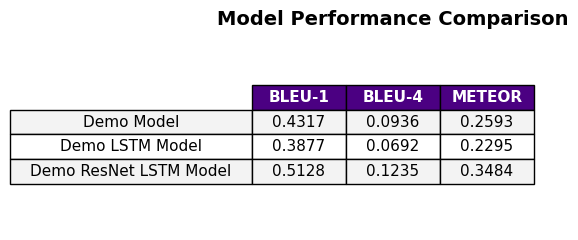

In [167]:
import matplotlib.pyplot as plt

# Data
models = ["Demo Model", "Demo LSTM Model", "Demo ResNet LSTM Model"]
metrics = ["BLEU-1", "BLEU-4", "METEOR"]
values = [
    [0.4317, 0.0936, 0.2593],
    [0.3877, 0.0692, 0.2295],
    [0.5128, 0.1235, 0.3484],
]

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis("off")

# Create the table
table = ax.table(
    cellText=values,
    rowLabels=models,
    colLabels=metrics,
    cellLoc="center",
    rowLoc="center",
    loc="center",
)

# Style adjustments
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

# Alternate row colors
for i, key in enumerate(table.get_celld()):
    cell = table.get_celld()[key]
    if key[0] == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#4B0082")  # header color (purple)
    elif key[0] % 2 == 1:
        cell.set_facecolor("#f3f3f3")
    else:
        cell.set_facecolor("white")

# Add title
plt.title("Model Performance Comparison", fontsize=14, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()


The ResNet + LSTM outperforms all models.

ResNet visual information extraction likely provides far better image embeddings, but the plain demo model outpeforms it probably due to weak image representations

Overall outputs are of low quality, likely due to parameter and training compute being unavailable

---